# **Comparative Study of Machine Learning Algorithms for Agricultural Pest Image Classification Using Visual Feature Extraction**

**Domain:** Agriculture & Computer Vision

## **Problem Statement**

Agricultural pests can damage crops and reduce farm productivity. Manual pest identification can be difficult for farmers, especially when expert support is not easily available. This project aims to classify pest images into different pest categories using machine learning models and compare their performance using different visual feature extraction methods.

## **Research Question**

Do pretrained CNN-extracted features improve agricultural pest image classification performance compared to raw pixel features across traditional machine learning algorithms?

## **Dataset(s)**

1. **Pest Dataset:** [Kaggle](https://www.kaggle.com/datasets/simranvolunesia/pest-dataset)

In [174]:
import warnings
warnings.filterwarnings("ignore")

In [175]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

## **Setting Paths to Datasets**

In [176]:
DATASETS_PATH = Path("../datasets/pest")

TRAIN_PATH = DATASETS_PATH / "train"
TEST_PATH = DATASETS_PATH / "test"

print(f"Path <{DATASETS_PATH}> Valid?", DATASETS_PATH.exists())
print(f"Path <{TRAIN_PATH}> Valid?", TRAIN_PATH.exists())
print(f"Path <{TEST_PATH}> Valid?", TEST_PATH.exists())

Path <../datasets/pest> Valid? True
Path <../datasets/pest/train> Valid? True
Path <../datasets/pest/test> Valid? True


## **Checking Class Folders**

In [177]:
class_names = sorted([folder.name for folder in TRAIN_PATH.iterdir() if folder.is_dir()])

print(class_names)

['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


## **Creating Image Dataframe**

In [178]:
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

records = []

for split_name, split_path in [("train", TRAIN_PATH), ("test", TEST_PATH)]:
    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            class_label = class_folder.name
            
            for image_path in class_folder.rglob('*'):
                if image_path.suffix.lower() in image_extensions:
                    records.append({
                        'split': split_name,
                        'class': class_label,
                        'image_path': str(image_path)
                    })
                    
df_images = pd.DataFrame(records)

print("Total Images: ", len(df_images))
df_images.head(5)

Total Images:  3150


,split,class,image_path
0,train,bollworm,../datasets/pest/train/bollworm/jpg_69 - Copy.jpg
1,train,bollworm,../datasets/pest/train/bollworm/jpg_92.jpg
2,train,bollworm,../datasets/pest/train/bollworm/jpg_86.jpg
3,train,bollworm,../datasets/pest/train/bollworm/jpg_51.jpg
4,train,bollworm,../datasets/pest/train/bollworm/jpg_3 - Copy.jpg


## **Counting Images Per Split & Class**

In [179]:
split_counts = df_images['split'].value_counts()
print(split_counts)

split
train    2700
test      450
Name: count, dtype: int64


In [180]:
class_counts = df_images.groupby(['split']).size()
print(class_counts, '\n\n')

class_counts = df_images.groupby(['split', 'class']).size().reset_index(name='count')
print(class_counts)

split
test      450
train    2700
dtype: int64 


    split        class  count
0    test       aphids     50
1    test     armyworm     50
2    test       beetle     50
3    test     bollworm     50
4    test  grasshopper     50
5    test        mites     50
6    test     mosquito     50
7    test       sawfly     50
8    test   stem_borer     50
9   train       aphids    300
10  train     armyworm    300
11  train       beetle    300
12  train     bollworm    300
13  train  grasshopper    300
14  train        mites    300
15  train     mosquito    300
16  train       sawfly    300
17  train   stem_borer    300


## **Plotting Class Distributions**

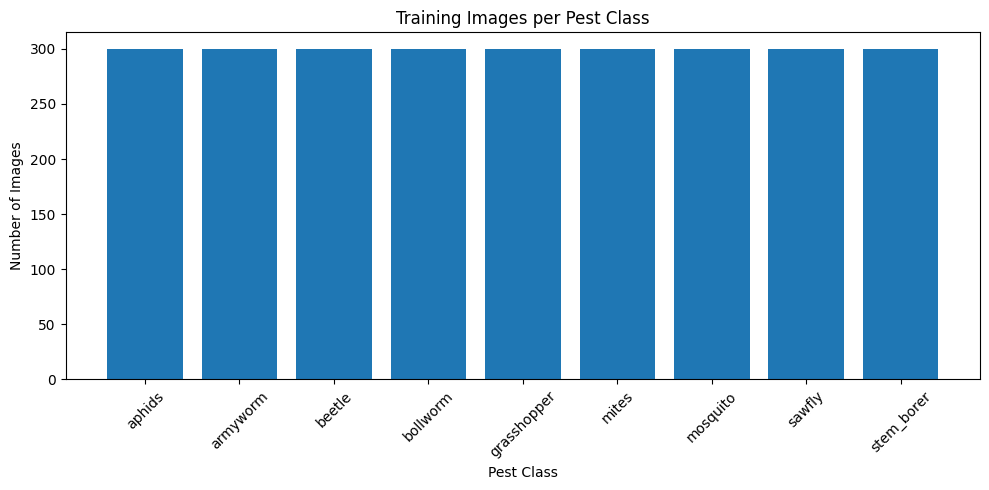

In [181]:
train_counts = class_counts[class_counts['split'] == 'train']

plt.figure(figsize=(10, 5))
plt.bar(train_counts['class'], train_counts['count'])
plt.title("Training Images per Pest Class")
plt.xlabel("Pest Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

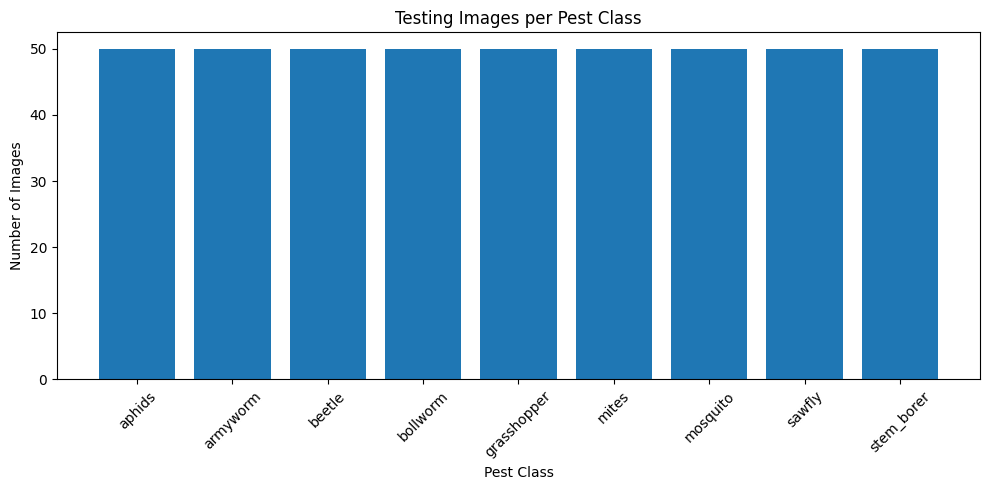

In [182]:
test_counts = class_counts[class_counts['split'] == 'test']

plt.figure(figsize=(10, 5))
plt.bar(test_counts['class'], test_counts['count'])
plt.title("Testing Images per Pest Class")
plt.xlabel("Pest Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Checking Image Sizes & Possible Corrupted Files**

In [183]:
image_info = []
corrupted_files = []

for _, row in df_images.iterrows():
    image_path = Path(row["image_path"])
    
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
            
        image_info.append({
            "image_path": str(image_path),
            "width": width,
            "height": height,
            "mode": mode
        })
            
    except (UnidentifiedImageError, OSError):
        corrupted_files.append(str(image_path))
        
df_info = pd.DataFrame(image_info)

print("Readable Images: ", len(df_info))
print("Corrupted Files: ", len(corrupted_files))

if corrupted_files:
    print("Few Corrupted Files")
    for img in corrupted_files[:10]:
        print(img)
        
df_info.head(5)

Readable Images:  3150
Corrupted Files:  0


,image_path,width,height,mode
0,../datasets/pest/train/bollworm/jpg_69 - Copy.jpg,252,200,RGB
1,../datasets/pest/train/bollworm/jpg_92.jpg,400,296,RGB
2,../datasets/pest/train/bollworm/jpg_86.jpg,284,178,RGB
3,../datasets/pest/train/bollworm/jpg_51.jpg,318,159,RGB
4,../datasets/pest/train/bollworm/jpg_3 - Copy.jpg,483,388,RGB


## **Image Size Summary**

In [184]:
df_info[['width', 'height']].describe()

,width,height
count,3150.000000,3150.000000
mean,354.030159,249.286349
std,273.610260,201.132764
min,180.000000,121.000000
25%,253.000000,178.000000
50%,275.000000,192.000000
75%,300.000000,225.000000
max,2500.000000,3088.000000


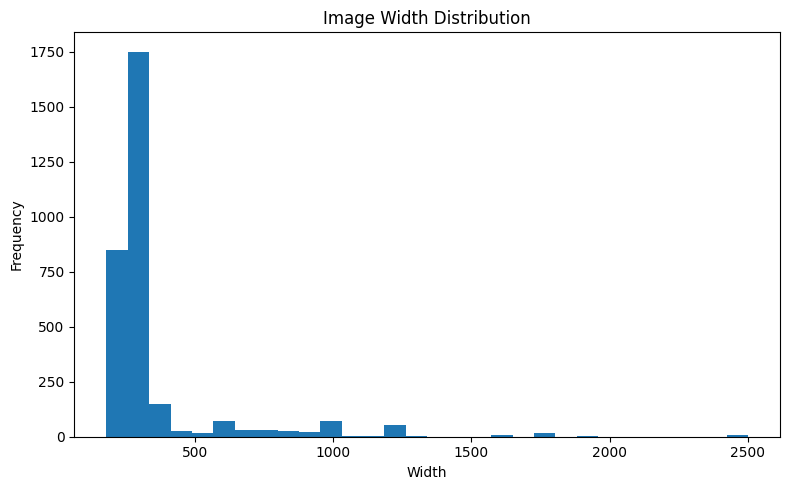

In [185]:
plt.figure(figsize=(8, 5))
plt.hist(df_info["width"], bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

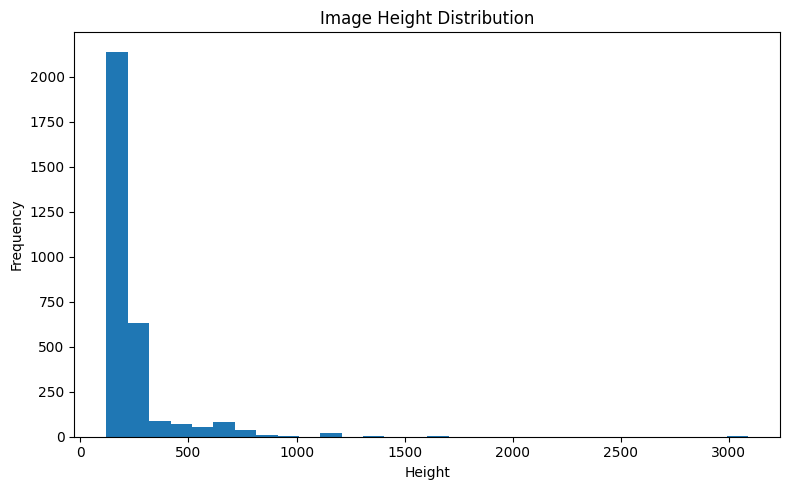

In [186]:
plt.figure(figsize=(8, 5))
plt.hist(df_info["height"], bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## **Sample Images from Each Class**

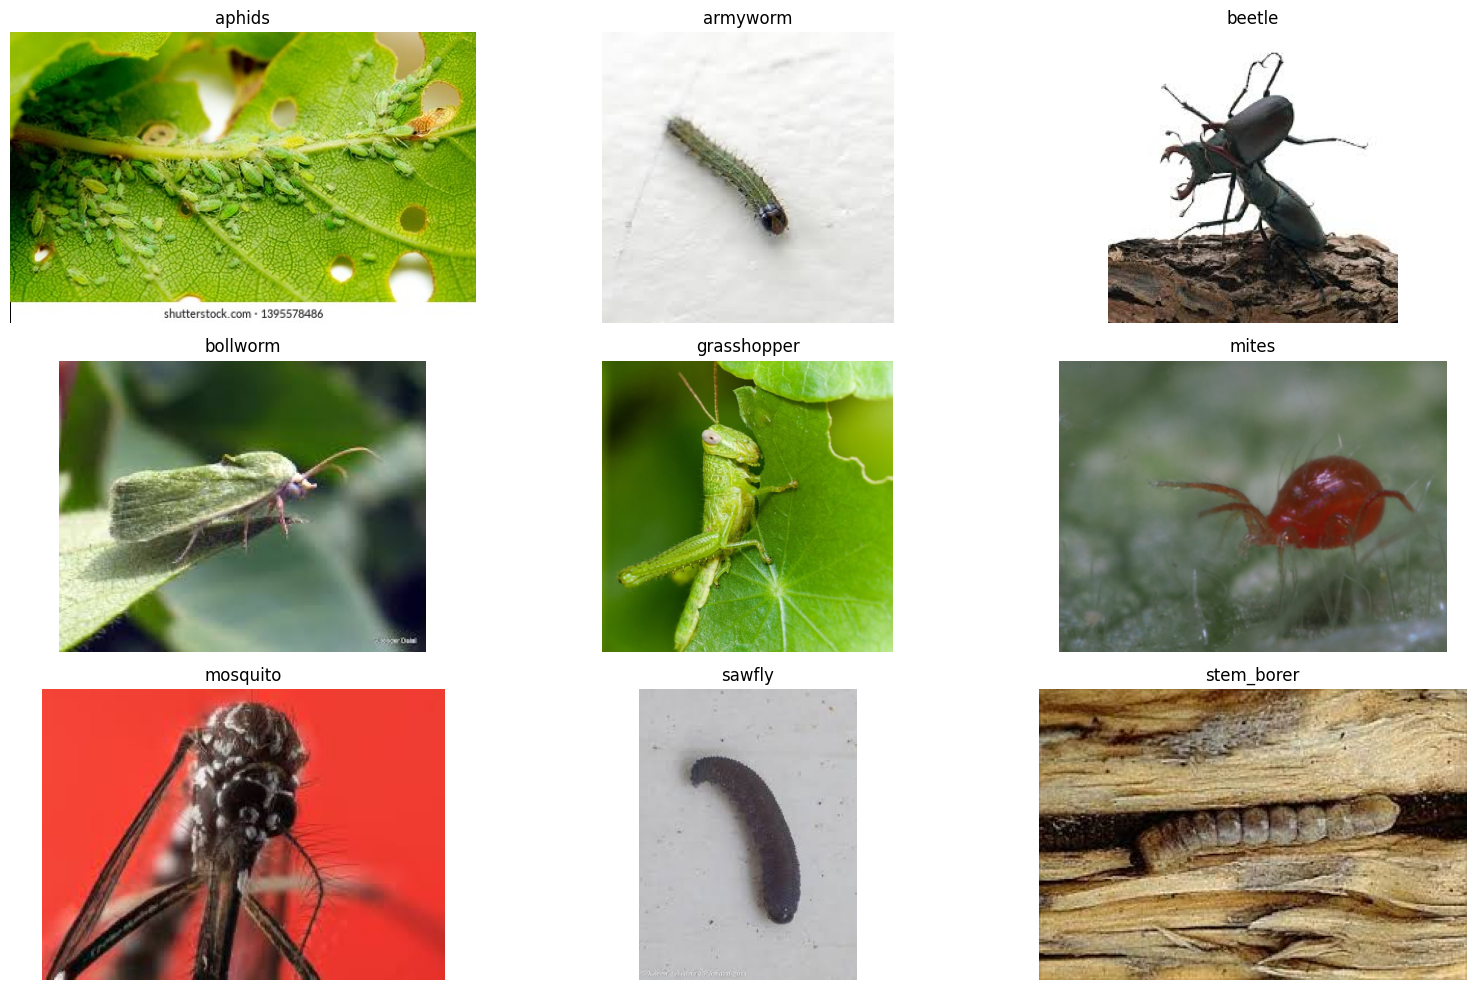

In [187]:
plt.figure(figsize=(16, 10))

for i, class_name in enumerate(class_names):
    sample_path = df_images[df_images['class'] == class_name]['image_path'].iloc[0]
    img = Image.open(sample_path)
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

## **Detecting Duplicate Files**

In [188]:
def calculate_file_hash(file_path):
    with open(file_path, "rb") as file:
        return hashlib.md5(file.read()).hexdigest()
    
hash_records = []

for _, row in df_images.iterrows():
    image_path = Path(row['image_path'])
    
    try:
        file_hash = calculate_file_hash(image_path)
        hash_records.append({
            'split': row['split'],
            'class': row['class'],
            'image_path': row['image_path'],
            'file_hash': file_hash
        })
    
    except OSError:
        ...
        
df_hashes = pd.DataFrame(hash_records)

print("Total images hashed: ", len(df_hashes))
df_hashes.head(5)

Total images hashed:  3150


,split,class,image_path,file_hash
0,train,bollworm,../datasets/pest/train/bollworm/jpg_69 - Copy.jpg,20ef448a5aa8667821eea8dac7cf4352
1,train,bollworm,../datasets/pest/train/bollworm/jpg_92.jpg,5db4587fc71e32252003bd1d13592dc8
2,train,bollworm,../datasets/pest/train/bollworm/jpg_86.jpg,047eefa65479e7297f867cc4ee87024f
3,train,bollworm,../datasets/pest/train/bollworm/jpg_51.jpg,e99af255579d5022a37a38cace310270
4,train,bollworm,../datasets/pest/train/bollworm/jpg_3 - Copy.jpg,0521491c56ba54530ed38d45c82506de


## **Duplicate Groups**

In [189]:
total_files = len(df_hashes)
unique_images = df_hashes["file_hash"].nunique()
duplicate_extra_files = total_files - unique_images

duplicate_group_count = (
    df_hashes.groupby("file_hash")
    .size()
    .gt(1)
    .sum()
)

files_in_duplicate_groups = (
    df_hashes.groupby("file_hash")
    .filter(lambda x: len(x) > 1)
    .shape[0]
)

print("Total image files:", total_files)
print("Unique original images:", unique_images)
print("Extra duplicate files to remove:", duplicate_extra_files)
print("Number of duplicate groups:", duplicate_group_count)
print("Files involved in duplicate groups:", files_in_duplicate_groups)

Total image files: 3150
Unique original images: 666
Extra duplicate files to remove: 2484
Number of duplicate groups: 623
Files involved in duplicate groups: 3107


In [190]:
# duplicate_groups = df_hashes.groupby('file_hash').filter(lambda x: len(x) > 1)

# num_duplicates = len(duplicate_groups)
# num_duplicate_groups = duplicate_groups['file_hash'].nunique()

# print("Total Duplicates: ", num_duplicates)
# print("Duplicate Groups: ", num_duplicate_groups)

In [191]:
# for file_hash, group in duplicate_groups.groupby("file_hash"):
#     print("\nDuplicate group:")
#     for path in group["image_path"].tolist():
#         print(path)

#     # Only show first 5 groups
#     if duplicate_groups["file_hash"].drop_duplicates().tolist().index(file_hash) == 4:
#         break

In [192]:
# sample_duplicates = files_in_duplicate_groups.sort_values(
#     by="image_path",
#     ascending=True
# ).head(10)

# plt.figure(figsize=(15, 6))

# for i, (row_label, row_data) in enumerate(sample_duplicates.iterrows()):
#     img = Image.open(row_data["image_path"])

#     plt.subplot(2, 5, i + 1)
#     plt.imshow(img)
#     plt.title(row_data["class"], fontsize=9)
#     plt.axis("off")

#     print(f"Data: {row_data['class']} - {row_data['image_path']}")

# plt.tight_layout()
# plt.show()

In [193]:
df_clean = df_hashes.drop_duplicates(
    subset="file_hash",
    keep="first"
).reset_index(drop=True)

print("Original image files:", len(df_hashes))
print("Unique images after duplicate removal:", len(df_clean))
print("Duplicate files removed:", len(df_hashes) - len(df_clean))

df_clean.head()

Original image files: 3150
Unique images after duplicate removal: 666
Duplicate files removed: 2484


,split,class,image_path,file_hash
0,train,bollworm,../datasets/pest/train/bollworm/jpg_69 - Copy.jpg,20ef448a5aa8667821eea8dac7cf4352
1,train,bollworm,../datasets/pest/train/bollworm/jpg_92.jpg,5db4587fc71e32252003bd1d13592dc8
2,train,bollworm,../datasets/pest/train/bollworm/jpg_86.jpg,047eefa65479e7297f867cc4ee87024f
3,train,bollworm,../datasets/pest/train/bollworm/jpg_51.jpg,e99af255579d5022a37a38cace310270
4,train,bollworm,../datasets/pest/train/bollworm/jpg_3 - Copy.jpg,0521491c56ba54530ed38d45c82506de


In [194]:
class_counts_clean = df_clean["class"].value_counts().sort_index()

print(class_counts_clean)

class
aphids         63
armyworm       71
beetle         62
bollworm       90
grasshopper    69
mites          63
mosquito       82
sawfly         70
stem_borer     96
Name: count, dtype: int64


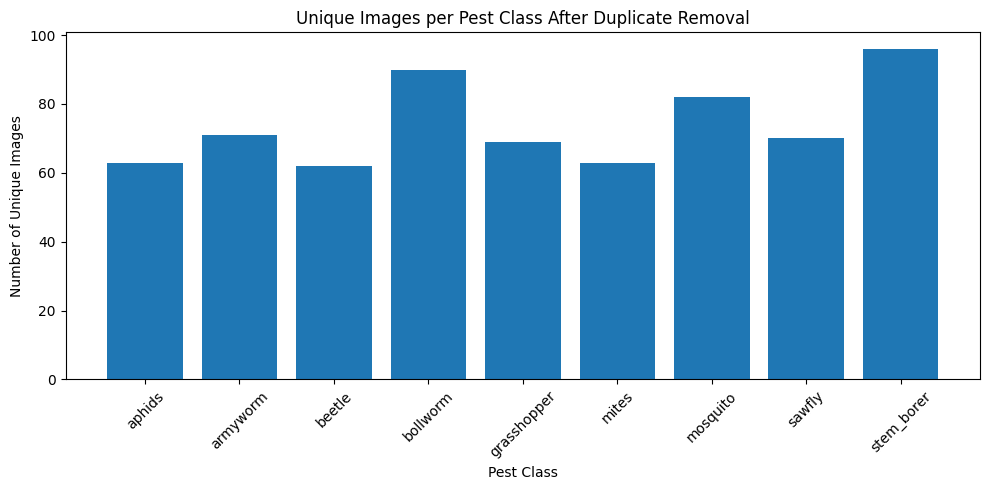

In [195]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts_clean.index, class_counts_clean.values)
plt.title("Unique Images per Pest Class After Duplicate Removal")
plt.xlabel("Pest Class")
plt.ylabel("Number of Unique Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [196]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean["class"]
)

print("Clean train size:", len(train_df))
print("Clean test size:", len(test_df))

print("\nTrain class count:")
print(train_df["class"].value_counts().sort_index())

print("\nTest class count:")
print(test_df["class"].value_counts().sort_index())

Clean train size: 532
Clean test size: 134

Train class count:
class
aphids         50
armyworm       57
beetle         50
bollworm       72
grasshopper    55
mites          50
mosquito       65
sawfly         56
stem_borer     77
Name: count, dtype: int64

Test class count:
class
aphids         13
armyworm       14
beetle         12
bollworm       18
grasshopper    14
mites          13
mosquito       17
sawfly         14
stem_borer     19
Name: count, dtype: int64


In [197]:
df_model = df_clean.copy()

In [198]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_model["label"] = label_encoder.fit_transform(df_model["class"])

print("Class mapping:")
for class_name, label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(class_name, "->", label)

Class mapping:
aphids -> 0
armyworm -> 1
beetle -> 2
bollworm -> 3
grasshopper -> 4
mites -> 5
mosquito -> 6
sawfly -> 7
stem_borer -> 8


In [199]:
from PIL import Image
import numpy as np

IMAGE_SIZE = (64, 64)

def extract_raw_pixel_features(image_path):
    img = Image.open(image_path).convert("L")
    img = img.resize(IMAGE_SIZE)

    img_array = np.array(img) / 255.0

    return img_array.flatten()

In [200]:
X_raw = []
y = []

for _, row in df_model.iterrows():
    try:
        features = extract_raw_pixel_features(row["image_path"])
        X_raw.append(features)
        y.append(row["label"])
    except Exception as e:
        print("Error processing:", row["image_path"])
        print(e)

X_raw = np.array(X_raw)
y = np.array(y)

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)

X_raw shape: (666, 4096)
y shape: (666,)


In [201]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

Training shape: (532, 4096)
Testing shape: (134, 4096)


In [202]:
from sklearn.preprocessing import StandardScaler

scaler_raw = StandardScaler()

X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw)
X_test_raw_scaled = scaler_raw.transform(X_test_raw)

In [203]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42)
}

In [204]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

raw_results = []

for model_name, model in models.items():
    print("Training:", model_name)

    model.fit(X_train_raw_scaled, y_train)

    y_pred = model.predict(X_test_raw_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    raw_results.append({
        "Feature Method": "Raw Pixels",
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1-score": f1
    })

df_raw_results = pd.DataFrame(raw_results)

df_raw_results_rounded = df_raw_results.copy()
for col in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score"]:
    df_raw_results_rounded[col] = df_raw_results_rounded[col].round(4)

df_raw_results_rounded

Training: Logistic Regression
Training: k-NN
Training: Decision Tree
Training: Random Forest
Training: SVM
Training: MLP


,Feature Method,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Raw Pixels,Logistic Regression,0.4254,0.4374,0.4164,0.4193
1,Raw Pixels,k-NN,0.2537,0.2826,0.2519,0.2406
2,Raw Pixels,Decision Tree,0.3358,0.3228,0.3284,0.3240
3,Raw Pixels,Random Forest,0.4254,0.4353,0.4140,0.4161
4,Raw Pixels,SVM,0.3358,0.3723,0.3207,0.3239
5,Raw Pixels,MLP,0.4328,0.4416,0.4290,0.4285


Best raw-pixel model: MLP


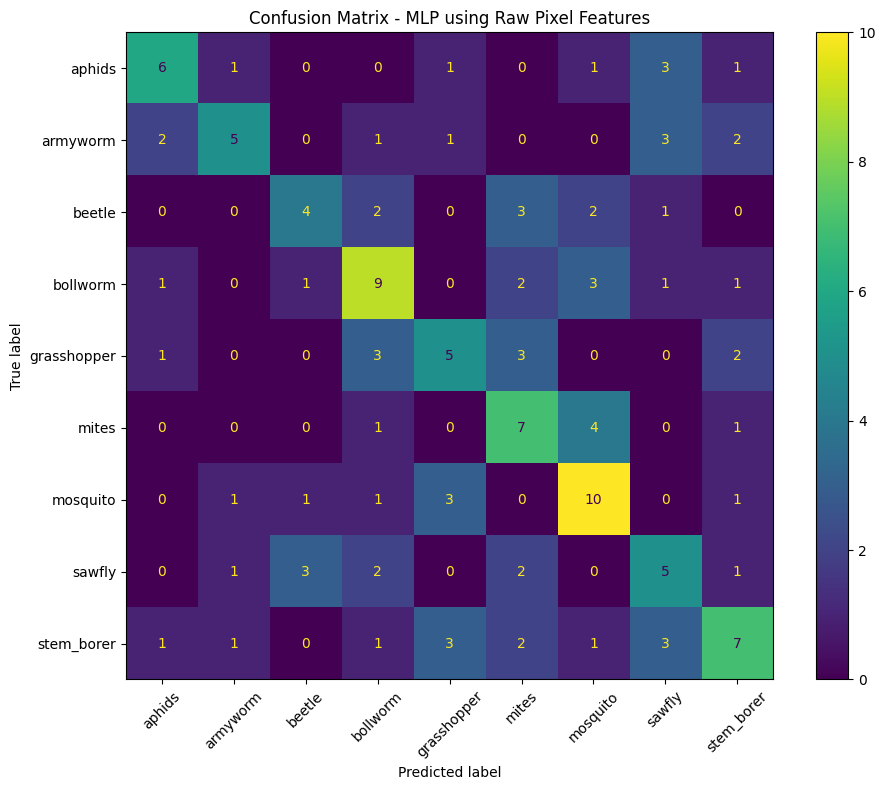

In [205]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_raw_model_name = df_raw_results.sort_values(
    "Macro F1-score",
    ascending=False
).iloc[0]["Model"]

print("Best raw-pixel model:", best_raw_model_name)

best_raw_model = models[best_raw_model_name]
y_pred_best_raw = best_raw_model.predict(X_test_raw_scaled)

cm = confusion_matrix(y_test, y_pred_best_raw)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_raw_model_name} using Raw Pixel Features")
plt.tight_layout()
plt.show()

In [206]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [207]:
cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42)
}

In [208]:
cv_results = []

for model_name, model in cv_models.items():
    print("Running 5-fold CV for:", model_name)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_raw,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "Feature Method": "Raw Pixels",
        "Model": model_name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Macro Precision Mean": scores["test_precision_macro"].mean(),
        "CV Macro Recall Mean": scores["test_recall_macro"].mean(),
        "CV Macro F1 Mean": scores["test_f1_macro"].mean(),
        "CV Macro F1 Std": scores["test_f1_macro"].std()
    })

df_cv_raw_results = pd.DataFrame(cv_results)

df_cv_raw_results_rounded = df_cv_raw_results.copy()

for col in df_cv_raw_results_rounded.columns:
    if "Mean" in col or "Std" in col:
        df_cv_raw_results_rounded[col] = df_cv_raw_results_rounded[col].round(4)

df_cv_raw_results_rounded

Running 5-fold CV for: Logistic Regression
Running 5-fold CV for: k-NN
Running 5-fold CV for: Decision Tree
Running 5-fold CV for: Random Forest
Running 5-fold CV for: SVM
Running 5-fold CV for: MLP


,Feature Method,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro Precision Mean,CV Macro Recall Mean,CV Macro F1 Mean,CV Macro F1 Std
0,Raw Pixels,Logistic Regression,0.3919,0.0140,0.3933,0.3788,0.3777,0.0151
1,Raw Pixels,k-NN,0.2268,0.0355,0.2674,0.2252,0.2084,0.0330
2,Raw Pixels,Decision Tree,0.3665,0.0387,0.3770,0.3530,0.3548,0.0400
3,Raw Pixels,Random Forest,0.4325,0.0272,0.4173,0.4106,0.3983,0.0224
4,Raw Pixels,SVM,0.3469,0.0130,0.3673,0.3253,0.3130,0.0138
5,Raw Pixels,MLP,0.4129,0.0251,0.4093,0.4001,0.3970,0.0264


In [209]:
mlp_epoch_tests = {
    "MLP 300 iterations": MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=42),
    "MLP 500 iterations": MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42),
    "MLP 1000 iterations": MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, random_state=42)
}

In [210]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [211]:
%pip install --upgrade certifi

Note: you may need to restart the kernel to use updated packages.


In [212]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [213]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [214]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [215]:
cnn_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")

MobileNetV2 loaded successfully.


In [216]:
def extract_cnn_features(image_path, model):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    features = model.predict(img_array, verbose=0)

    return features.flatten()

In [217]:
X_cnn = []
y_cnn = []

for idx, row in df_model.iterrows():
    try:
        features = extract_cnn_features(row["image_path"], cnn_model)

        X_cnn.append(features)
        y_cnn.append(row["label"])

    except Exception as e:
        print("Error processing:", row["image_path"])
        print(e)

    if (idx + 1) % 50 == 0:
        print("Processed images:", idx + 1)

X_cnn = np.array(X_cnn)
y_cnn = np.array(y_cnn)

print("X_cnn shape:", X_cnn.shape)
print("y_cnn shape:", y_cnn.shape)

Processed images: 50
Processed images: 100
Processed images: 150
Processed images: 200
Processed images: 250
Processed images: 300
Processed images: 350
Processed images: 400
Processed images: 450
Processed images: 500
Processed images: 550
Processed images: 600
Processed images: 650
X_cnn shape: (666, 1280)
y_cnn shape: (666,)


In [218]:
OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

np.save(OUTPUT_PATH / "X_cnn_features_clean_666.npy", X_cnn)
np.save(OUTPUT_PATH / "y_cnn_labels_clean_666.npy", y_cnn)

print("CNN features saved.")

CNN features saved.


In [219]:
cv_cnn_results = []

for model_name, model in cv_models.items():
    print("Running 5-fold CV for:", model_name)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_cnn,
        y_cnn,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_cnn_results.append({
        "Feature Method": "CNN Features",
        "Model": model_name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Macro Precision Mean": scores["test_precision_macro"].mean(),
        "CV Macro Recall Mean": scores["test_recall_macro"].mean(),
        "CV Macro F1 Mean": scores["test_f1_macro"].mean(),
        "CV Macro F1 Std": scores["test_f1_macro"].std()
    })

df_cv_cnn_results = pd.DataFrame(cv_cnn_results)

df_cv_cnn_results_rounded = df_cv_cnn_results.copy()

for col in df_cv_cnn_results_rounded.columns:
    if "Mean" in col or "Std" in col:
        df_cv_cnn_results_rounded[col] = df_cv_cnn_results_rounded[col].round(4)

df_cv_cnn_results_rounded

Running 5-fold CV for: Logistic Regression
Running 5-fold CV for: k-NN
Running 5-fold CV for: Decision Tree
Running 5-fold CV for: Random Forest
Running 5-fold CV for: SVM
Running 5-fold CV for: MLP


,Feature Method,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro Precision Mean,CV Macro Recall Mean,CV Macro F1 Mean,CV Macro F1 Std
0,CNN Features,Logistic Regression,0.8109,0.0358,0.8175,0.8117,0.8110,0.0367
1,CNN Features,k-NN,0.6637,0.0294,0.6871,0.6682,0.6578,0.0324
2,CNN Features,Decision Tree,0.4519,0.0409,0.4595,0.4527,0.4518,0.0431
3,CNN Features,Random Forest,0.7343,0.0308,0.7373,0.7281,0.7230,0.0374
4,CNN Features,SVM,0.7703,0.0305,0.7918,0.7651,0.7713,0.0349
5,CNN Features,MLP,0.8139,0.0293,0.8226,0.8148,0.8118,0.0326


In [220]:
df_cv_all_results = pd.concat(
    [df_cv_raw_results, df_cv_cnn_results],
    ignore_index=True
)

df_cv_all_results_rounded = df_cv_all_results.copy()

for col in df_cv_all_results_rounded.columns:
    if "Mean" in col or "Std" in col:
        df_cv_all_results_rounded[col] = df_cv_all_results_rounded[col].round(4)

df_cv_all_results_rounded.sort_values(
    by="CV Macro F1 Mean",
    ascending=False
)

,Feature Method,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro Precision Mean,CV Macro Recall Mean,CV Macro F1 Mean,CV Macro F1 Std
11,CNN Features,MLP,0.8139,0.0293,0.8226,0.8148,0.8118,0.0326
6,CNN Features,Logistic Regression,0.8109,0.0358,0.8175,0.8117,0.8110,0.0367
10,CNN Features,SVM,0.7703,0.0305,0.7918,0.7651,0.7713,0.0349
9,CNN Features,Random Forest,0.7343,0.0308,0.7373,0.7281,0.7230,0.0374
7,CNN Features,k-NN,0.6637,0.0294,0.6871,0.6682,0.6578,0.0324
8,CNN Features,Decision Tree,0.4519,0.0409,0.4595,0.4527,0.4518,0.0431
3,Raw Pixels,Random Forest,0.4325,0.0272,0.4173,0.4106,0.3983,0.0224
5,Raw Pixels,MLP,0.4129,0.0251,0.4093,0.4001,0.3970,0.0264
0,Raw Pixels,Logistic Regression,0.3919,0.0140,0.3933,0.3788,0.3777,0.0151
2,Raw Pixels,Decision Tree,0.3665,0.0387,0.3770,0.3530,0.3548,0.0400


## **TESTING ON REAL DATA**

In [258]:
UNLABELED_PATH = Path("../datasets/real-world")

print("Real-world test path exists:", UNLABELED_PATH.exists())

Real-world test path exists: True


In [259]:
unlabeled_image_paths = []

for image_path in UNLABELED_PATH.rglob("*"):
    if image_path.suffix.lower() in image_extensions:
        unlabeled_image_paths.append(str(image_path))

print("Total unlabeled images found:", len(unlabeled_image_paths))
unlabeled_image_paths[:5]

Total unlabeled images found: 4


['../datasets/real-world/aphid.jpeg',
 '../datasets/real-world/grasshopper.jpeg',
 '../datasets/real-world/mosquito.jpeg',
 '../datasets/real-world/pikachu.jpeg']

In [260]:
X_unlabeled_cnn = []
valid_unlabeled_paths = []

for idx, image_path in enumerate(unlabeled_image_paths):
    try:
        features = extract_cnn_features(image_path, cnn_model)

        X_unlabeled_cnn.append(features)
        valid_unlabeled_paths.append(image_path)

    except Exception as e:
        print("Error processing:", image_path)
        print(e)

    if (idx + 1) % 50 == 0:
        print("Processed images:", idx + 1)

X_unlabeled_cnn = np.array(X_unlabeled_cnn)

print("X_unlabeled_cnn shape:", X_unlabeled_cnn.shape)

X_unlabeled_cnn shape: (4, 1280)


In [261]:
unlabeled_pred = final_model.predict(X_unlabeled_cnn)

unlabeled_pred_classes = label_encoder.inverse_transform(unlabeled_pred)

df_unlabeled_predictions = pd.DataFrame({
    "Image Path": valid_unlabeled_paths,
    "Predicted Class": unlabeled_pred_classes
})

df_unlabeled_predictions

,Image Path,Predicted Class
0,../datasets/real-world/aphid.jpeg,aphids
1,../datasets/real-world/grasshopper.jpeg,grasshopper
2,../datasets/real-world/mosquito.jpeg,mosquito
3,../datasets/real-world/pikachu.jpeg,mites


In [262]:
unlabeled_pred_probs = final_model.predict_proba(X_unlabeled_cnn)

confidence_scores = unlabeled_pred_probs.max(axis=1)

df_unlabeled_predictions["Confidence"] = confidence_scores

df_unlabeled_predictions["Confidence"] = df_unlabeled_predictions["Confidence"].round(4)

df_unlabeled_predictions

,Image Path,Predicted Class,Confidence
0,../datasets/real-world/aphid.jpeg,aphids,0.9404
1,../datasets/real-world/grasshopper.jpeg,grasshopper,0.9998
2,../datasets/real-world/mosquito.jpeg,mosquito,0.9582
3,../datasets/real-world/pikachu.jpeg,mites,0.4226


In [263]:
UNKNOWN_THRESHOLD = 0.60

df_unlabeled_predictions["Final Prediction"] = df_unlabeled_predictions.apply(
    lambda row: row["Predicted Class"] if row["Confidence"] >= UNKNOWN_THRESHOLD else "Unknown / Not in trained classes",
    axis=1
)

df_unlabeled_predictions

,Image Path,Predicted Class,Confidence,Final Prediction
0,../datasets/real-world/aphid.jpeg,aphids,0.9404,aphids
1,../datasets/real-world/grasshopper.jpeg,grasshopper,0.9998,grasshopper
2,../datasets/real-world/mosquito.jpeg,mosquito,0.9582,mosquito
3,../datasets/real-world/pikachu.jpeg,mites,0.4226,Unknown / Not in trained classes


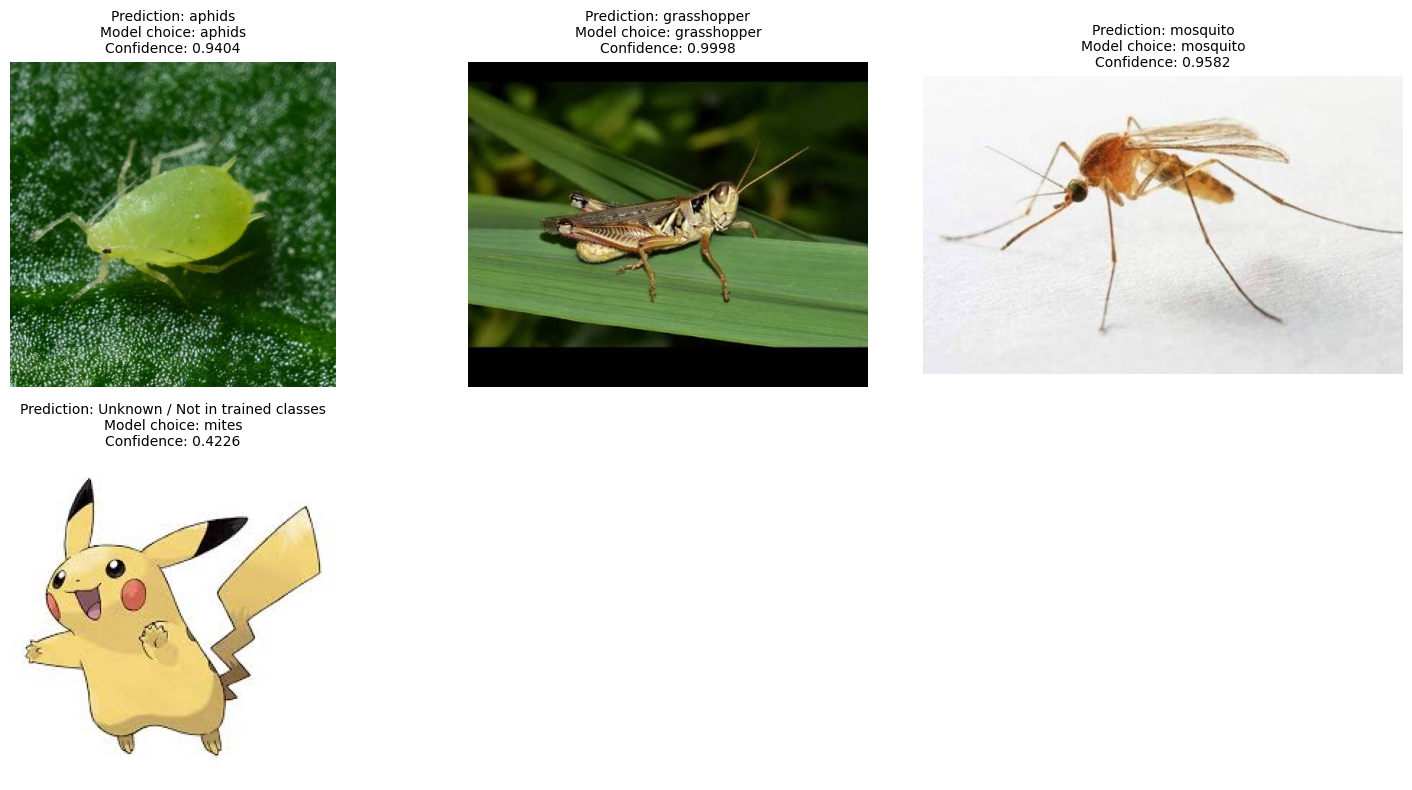

In [264]:
num_images = min(len(df_unlabeled_predictions), 12)

cols = 3
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(15, rows * 4))

for i in range(num_images):
    row = df_unlabeled_predictions.iloc[i]
    img = Image.open(row["Image Path"]).convert("RGB")

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)

    title = (
        f"Prediction: {row['Final Prediction']}\n"
        f"Model choice: {row['Predicted Class']}\n"
        f"Confidence: {row['Confidence']:.4f}"
    )

    plt.title(title, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()